## Read the data

In [2]:
import pandas as pd
sales_df=pd.read_csv('Superstore_Sales_Data.csv')
sales_df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
sales_df.shape

(9800, 18)

In [5]:
sales_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [7]:
sales_df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000



## Data Cleaning

In [8]:
#finding missing values
sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
sales_df[sales_df['Postal Code'].isnull()][['City', 'State', 'Postal Code']]

,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


In [10]:
# Directly fill the missing values for Burlington, Vermont
sales_df['Postal Code'] = sales_df['Postal Code'].fillna(5401.0)

In [12]:
#changing to string from float so it does not display zero at the end
sales_df['Postal Code'] = sales_df['Postal Code'].astype(int).astype(str)
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [13]:
#no null values are present now
sales_df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [15]:
#check for duplicates
sales_df.duplicated().sum()

np.int64(0)

In [16]:
duplicate_columns = [col for col in sales_df.columns if col != 'Row ID']
print("Duplicates ignoring Row ID:", sales_df.duplicated(subset=duplicate_columns).sum())

Duplicates ignoring Row ID: 1


In [18]:
# Drop the duplicate row based on all columns EXCEPT Row ID
duplicate_columns = [col for col in sales_df.columns if col != 'Row ID']
sales_df.drop_duplicates(subset=duplicate_columns, inplace=True)

In [20]:
#convert date
sales_df['Order Date']=pd.to_datetime(sales_df['Order Date'],format='mixed')

In [21]:
sales_df['Month']=sales_df['Order Date'].dt.month_name()
sales_df['Month'].head() #change name to Order Month


0      August
1      August
2    December
3    November
4    November
Name: Month, dtype: object

In [22]:
#add new column Order Month
sales_df.drop(columns=['Month'],inplace=True)
sales_df['Order Month']=sales_df['Order Date'].dt.month_name()
sales_df['Order Month'].head()

0      August
1      August
2    December
3    November
4    November
Name: Order Month, dtype: object

In [23]:
#add new Order Year column
sales_df['Order Year']=sales_df['Order Date'].dt.year
sales_df['Order Year'].head()

0    2017
1    2017
2    2017
3    2016
4    2016
Name: Order Year, dtype: int32

In [24]:
sales_df['Ship Date']=pd.to_datetime(sales_df['Ship Date'],format='mixed')

In [25]:
#add new column Ship Month
sales_df['Ship Month']=sales_df['Ship Date'].dt.month_name()
sales_df['Ship Month'].head()

0    November
1    November
2        June
3     October
4     October
Name: Ship Month, dtype: object

In [26]:
#add new column Ship Year
sales_df['Ship Year']=sales_df['Ship Date'].dt.year
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Month,Order Year,Ship Month,Ship Year
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,August,2017,November,2017
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,August,2017,November,2017
2,3,CA-2017-138688,2017-12-06,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,December,2017,June,2017
3,4,US-2016-108966,2016-11-10,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,November,2016,October,2016
4,5,US-2016-108966,2016-11-10,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,November,2016,October,2016


## Performing EDA

In [4]:
import matplotlib.pyplot as plt

<Axes: xlabel='Region'>

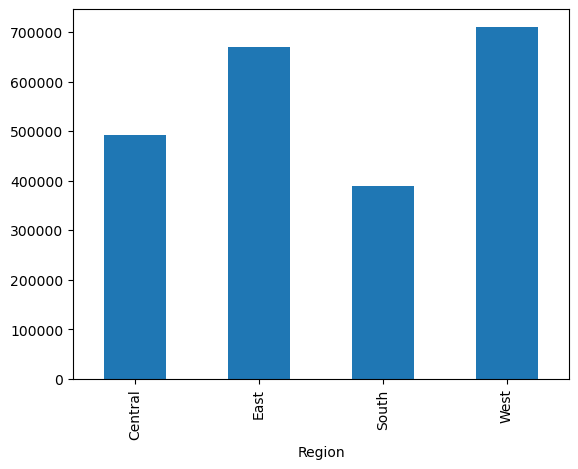

In [29]:
# Region by Sales
sales_df.groupby("Region")["Sales"].sum().plot(kind="bar")

## Key Findings
* **Highest Sales:** East is the region with highest sales
* **Lowest Sales:** South is the region with least sales

In [7]:
#Category Wise Sales
category_sales=sales_df.groupby(['Category'])['Sales'].sum()

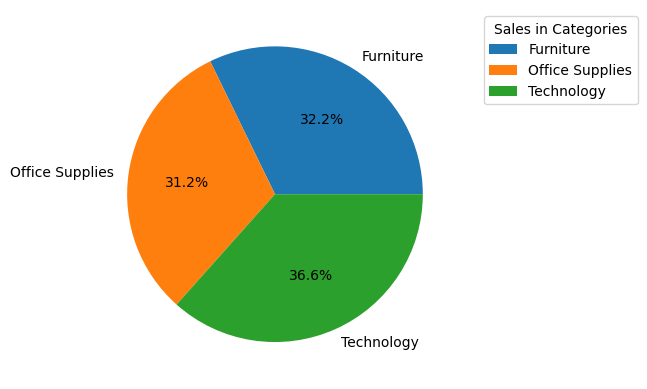

In [14]:
mylabels=category_sales.index
plt.pie(category_sales.values,labels=mylabels,autopct='%1.1f%%')
plt.legend(title='Sales in Categories',bbox_to_anchor=(1.5, 1),loc='upper right')
plt.show()

## Key Findings
* **Technology Category:** Technology category has the highest sales.
* **Other Categoires:** Other categories has almost same sales and not much less than technology category
* **Office Supplies:** This category has the lowest sales.

In [21]:
country_sales=sales_df.groupby(['Country'])['Sales'].sum()
print(country_sales)

Country
United States    2.261537e+06
Name: Sales, dtype: float64


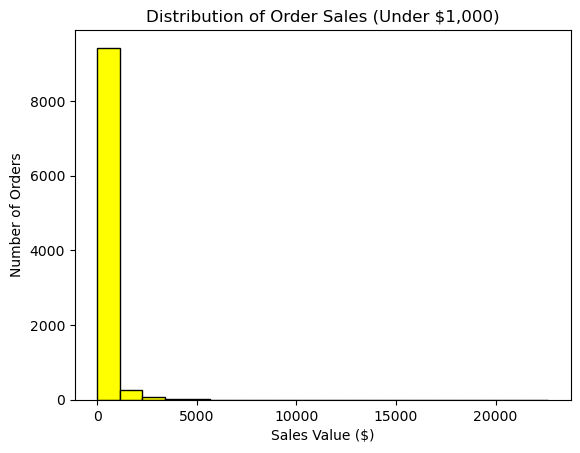

In [67]:
plt.hist(sales_df['Sales'],color='yellow',bins=20,edgecolor='black')
plt.title('Distribution of Order Sales (Under $1,000)')
plt.xlabel('Sales Value ($)')
plt.ylabel('Number of Orders')
plt.show()


### Key Findings:
* **High Concentration of Low-Value Orders:** The distribution is heavily right-skewed. The vast majority of transaction values are concentrated under **\$1,000**, with a massive spike in the **\$0 to \$100** range.
* **Presence of Extreme Outliers:** While everyday transactions are small, the X-axis stretches all the way to **\$20,000+**. This indicates the presence of a few high-value enterprise or bulk orders that significantly skew the total revenue.

In [22]:
#subcategory Sales
subcategory_sales=sales_df.groupby(['Sub-Category'])['Sales'].sum()
print(subcategory_sales)

Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64


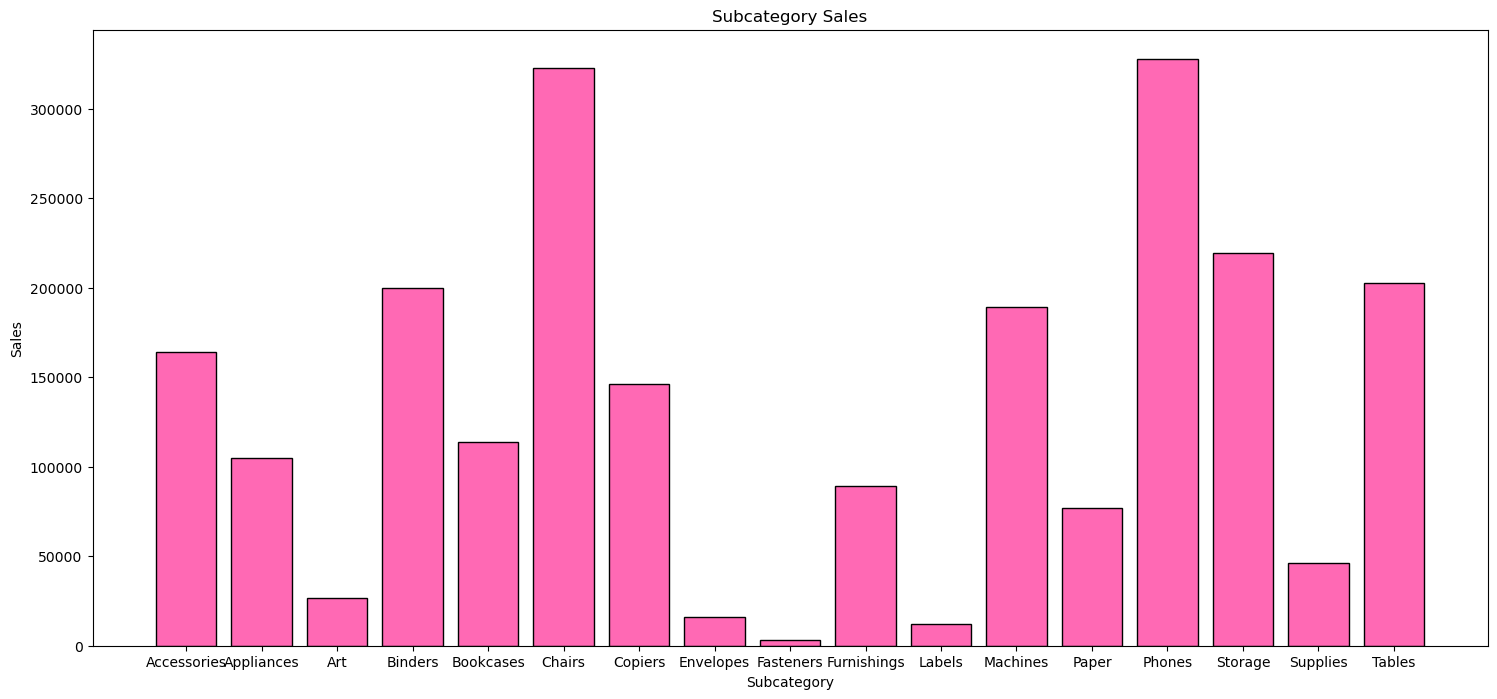

In [25]:
plt.figure(figsize=(18,8))
plt.bar(subcategory_sales.index,subcategory_sales.values,color='hotpink',edgecolor='black')
plt.xlabel('Subcategory')
plt.ylabel('Sales')
plt.title('Subcategory Sales')
plt.show()

### Key Findings:
* **Top Revenue Drivers:** **Phones** (\$327,782) and **Chairs** (\$322,822) are the highest-grossing sub-categories, closely followed by **Storage** (\$219,343) and **Binders** (\$200,028). 
* **Underperforming Categories:** **Fasteners** (\$3,001), **Labels** (\$12,347), and **Envelopes** (\$16,128) generate the least amount of raw revenue.

In [37]:
#top 10 States by Sales
top_states=sales_df.groupby(['State'])['Sales'].sum().nlargest(10)
print(top_states)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


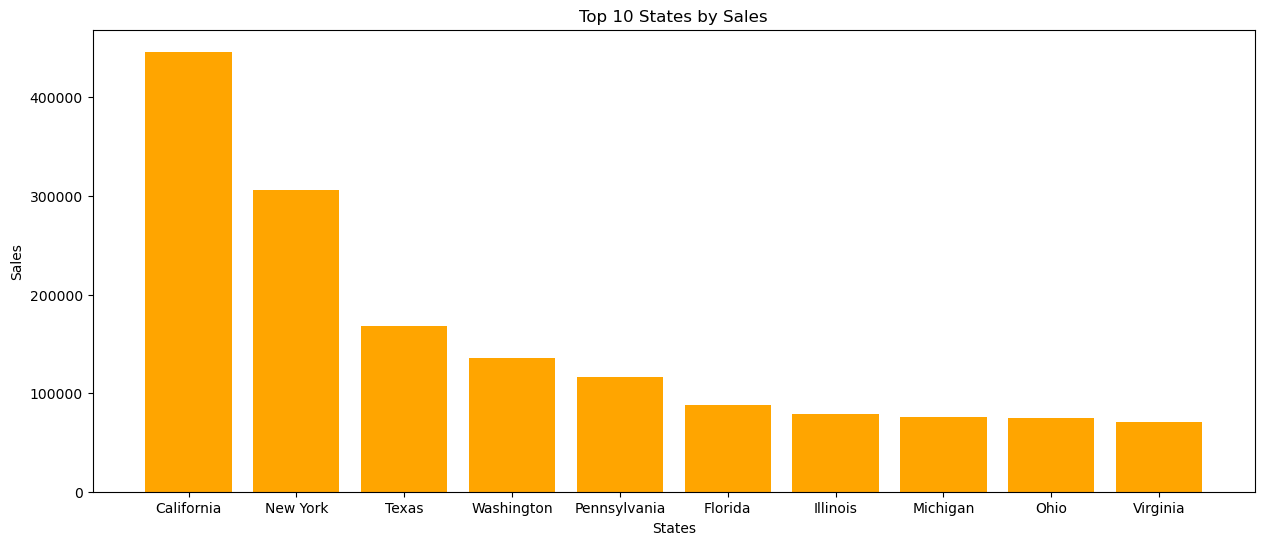

In [44]:
plt.figure(figsize=(15,6))
plt.bar(top_states.index,top_states.values,color='orange')
plt.xlabel('States')
plt.ylabel('Sales')
plt.title('Top 10 States by Sales')
plt.show()

In [39]:
#top 5 cities by sales
top_cities=sales_df.groupby(['City'])['Sales'].sum().nlargest(5)
print(top_cities)

City
New York City    252462.547
Los Angeles      173420.181
Seattle          116106.322
San Francisco    109041.120
Philadelphia     108841.749
Name: Sales, dtype: float64


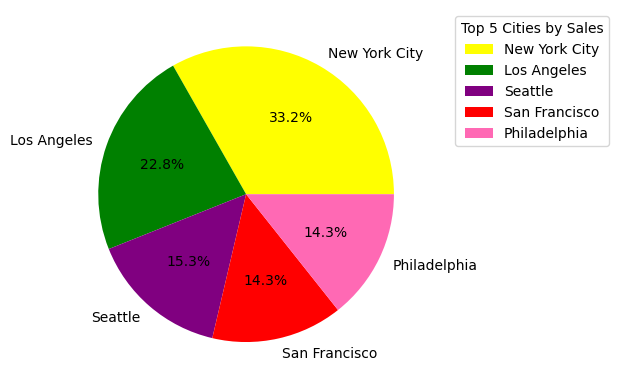

In [43]:
mylabels=top_cities.index
color_list=['yellow','green','purple','red','hotpink']
plt.pie(top_cities.values,labels=mylabels,colors=color_list,autopct='%1.1f%%')
plt.legend(bbox_to_anchor=(1.5,1),title='Top 5 Cities by Sales')
plt.show()

In [45]:
#Sales by Segment
segment_sales=sales_df.groupby(['Segment'])['Sales'].sum()
print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


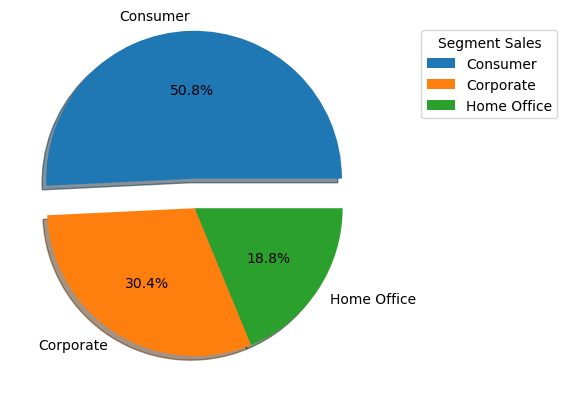

In [57]:
mylabels=segment_sales.index
myexplode=[0.2,0,0]
plt.pie(segment_sales.values,explode=myexplode,shadow=True,labels=mylabels,autopct='%1.1f%%')
plt.legend(title='Segment Sales',bbox_to_anchor=(1.5,1),loc='upper right')
plt.show()

In [47]:
#top 5 customers 
top_customers=sales_df.groupby('Customer Name')['Sales'].sum().nlargest(5)
print(top_customers)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


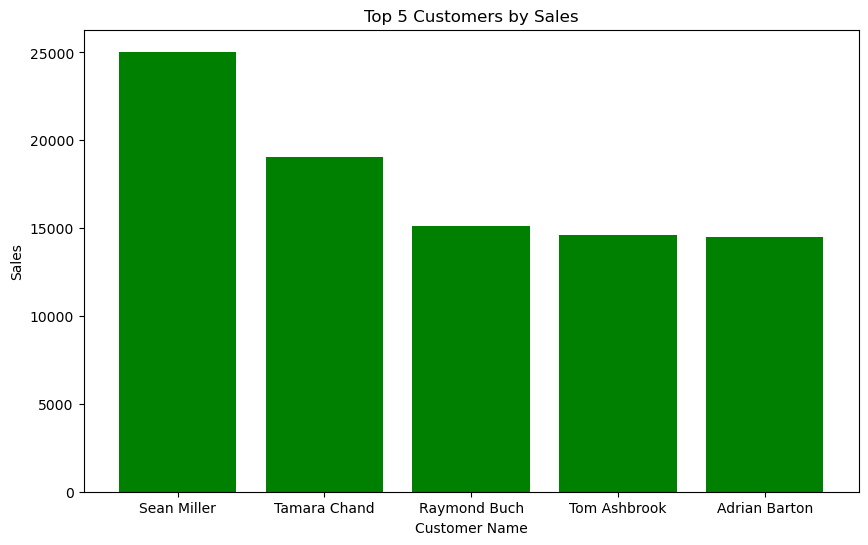

In [50]:
plt.figure(figsize=(10,6))
plt.bar(top_customers.index,top_customers.values,color='green')
plt.xlabel('Customer Name')
plt.ylabel('Sales')
plt.title('Top 5 Customers by Sales')
plt.show()

## Key Findings
* **Top Customer:** Sean Miller is the top customer with sales of $25000

In [48]:
# Group by Category and Sub-Category
cat_subcat = sales_df.groupby(['Category', 'Sub-Category'])['Sales'].sum().unstack(level=0)
cat_subcat

Category,Furniture,Office Supplies,Technology
Sub-Category,,,
Accessories,NaN,NaN,164186.700
Appliances,NaN,104618.403,NaN
Art,NaN,26705.410,NaN
Binders,NaN,200028.785,NaN
Bookcases,113813.1987,NaN,NaN
Chairs,322822.7310,NaN,NaN
Copiers,NaN,NaN,146248.094
Envelopes,NaN,16128.046,NaN
Fasteners,NaN,3001.960,NaN


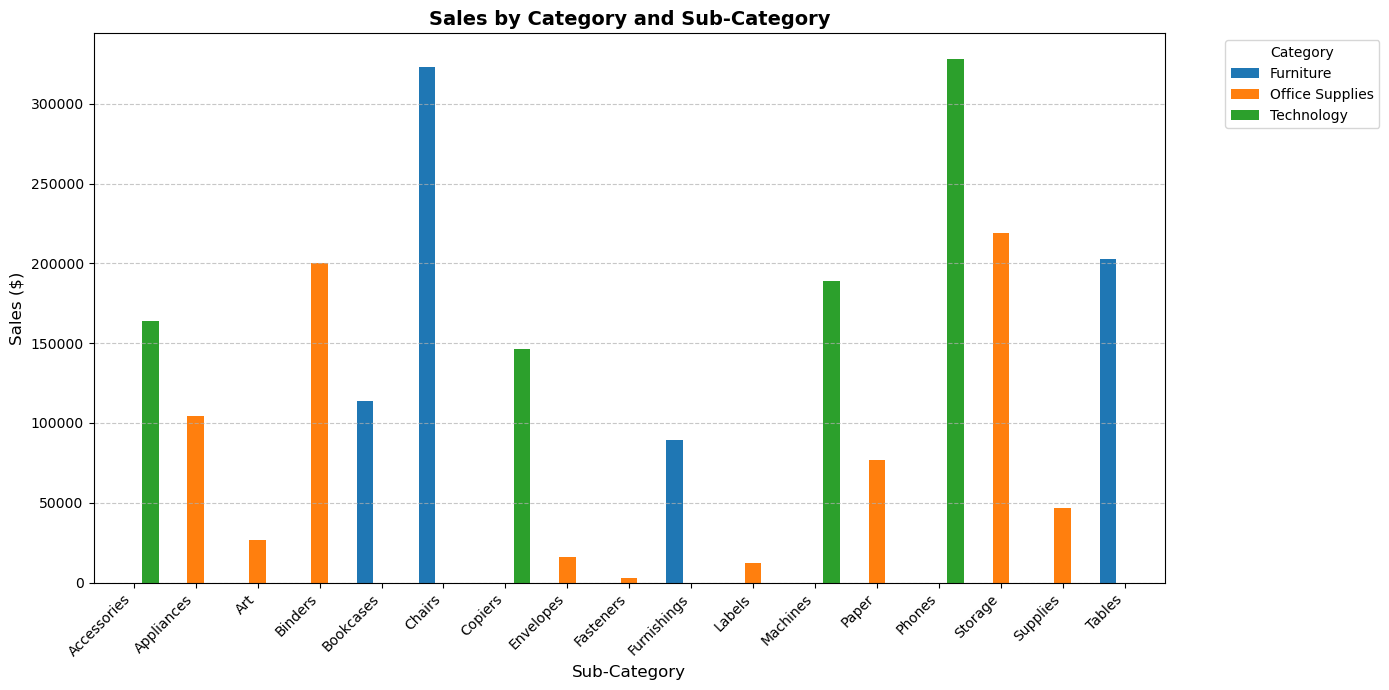

In [62]:
# Grouped Barchart
cat_subcat.plot(kind='bar', figsize=(14, 7), width=0.8)

# Add labels and formatting
plt.title('Sales by Category and Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Sub-Category', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [51]:
#Top 3 products by sales
top_products=sales_df.groupby('Product Name')['Sales'].sum().nlargest(3)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
Name: Sales, dtype: float64

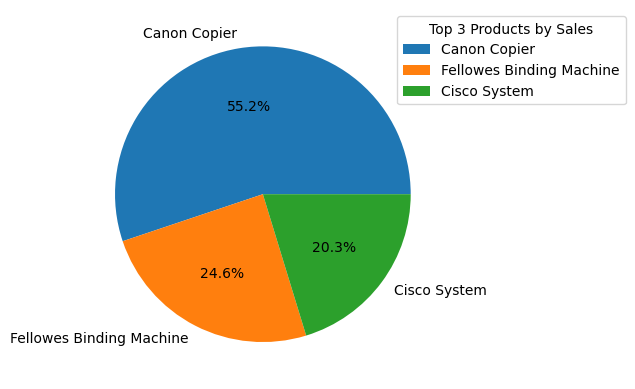

In [55]:
mylabels=['Canon Copier','Fellowes Binding Machine','Cisco System']
plt.pie(top_products.values,labels=mylabels,autopct='%1.1f%%')
plt.legend(title='Top 3 Products by Sales',loc='upper right',bbox_to_anchor=(1.5,1))
plt.show()

In [ ]:
# Calculate shipping days
sales_df['Ship_Delay'] = (sales_df['Ship Date'] - sales_df['Order Date']).dt.days
print(sales_df['Ship_Delay'].describe())